# Laboratorio 9 Spark MLlib
### Sebastian Juarez - 21471
### Juan Pablo Cordón - 21458

### Avances

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.getOrCreate()

path = "./salidas/accidentes_2013_2023_combined.csv"

df = (spark.read
      .option("header", True)
      .option("inferSchema", True)
      .csv(path))

print(f"Total filas: {df.count():,}")
df.printSchema()

Total filas: 297,436
root
 |-- anio: integer (nullable = true)
 |-- ano_ocu: double (nullable = true)
 |-- area_geo_ocu: string (nullable = true)
 |-- areag_ocu: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- causa_acc: string (nullable = true)
 |-- color_veh: string (nullable = true)
 |-- corre_base: double (nullable = true)
 |-- depto_ocu: string (nullable = true)
 |-- dia_ocu: double (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- edad_con: string (nullable = true)
 |-- edad_per: string (nullable = true)
 |-- edad_pil: string (nullable = true)
 |-- edad_quinquenales: string (nullable = true)
 |-- edad_vic: string (nullable = true)
 |-- estado_con: string (nullable = true)
 |-- estado_pil: string (nullable = true)
 |-- fall_les: string (nullable = true)
 |-- fallecidos_lesionados: string (nullable = true)
 |-- filter_$: string (nullable = true)
 |-- g_edad: string (nullable = true)
 |-- g_edad_2: string (nullable = true)
 |-- g_edad_60ymas: s

## 1. Preparacion/limpieza de los datos del DF

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import types as T
import os

# Normaliza fecha
mes_map = {
    "enero":1,"ene":1,"febrero":2,"feb":2,"marzo":3,"mar":3,"abril":4,"abr":4,
    "mayo":5,"may":5,"junio":6,"jun":6,"julio":7,"jul":7,"agosto":8,"ago":8,
    "septiembre":9,"setiembre":9,"sep":9,"set":9,"octubre":10,"oct":10,
    "noviembre":11,"nov":11,"diciembre":12,"dic":12
}
mmap = F.create_map(*[F.lit(x) for kv in mes_map.items() for x in kv])

df = (df
      .withColumn("anio_int", F.expr("try_cast(anio as int)"))
      .withColumn("mes_txt",  F.lower(F.coalesce(F.col("mes_ocu").cast("string"), F.lit(""))))
      .withColumn("mes_num",  F.coalesce(F.expr("try_cast(mes_ocu as int)"), F.element_at(mmap, F.col("mes_txt"))))
      .withColumn("dia_int",  F.expr("try_cast(dia_ocu as int)"))
      .withColumn("tipo_eve_norm", F.lower(F.trim(F.col("tipo_eve"))))
)

# Normaliza hora
cand_hora = F.coalesce(F.col("hora_ocu").cast("string"),
                       F.col("g_hora").cast("string"),
                       F.col("g_hora_5").cast("string"))
hstr = F.regexp_extract(F.coalesce(cand_hora, F.lit("")), r"(\d{1,2})", 1)
hora_num = F.when(hstr.rlike(r"^\d{1,2}$"), hstr.cast("int"))
df = df.withColumn("hora", F.when((hora_num >= 0) & (hora_num <= 23), hora_num))

# Normaliza zona
zona_col = "zona_ciudad" if "zona_ciudad" in df.columns else ("zona_ocu" if "zona_ocu" in df.columns else None)
if zona_col:
    df = df.withColumn("zona_str", F.col(zona_col).cast("string"))

num2name = {
  1:"Guatemala",2:"El Progreso",3:"Sacatepéquez",4:"Chimaltenango",5:"Escuintla",
  6:"Santa Rosa",7:"Sololá",8:"Totonicapán",9:"Quetzaltenango",10:"Suchitepéquez",
  11:"Retalhuleu",12:"San Marcos",13:"Huehuetenango",14:"Quiché",15:"Baja Verapaz",
  16:"Alta Verapaz",17:"Petén",18:"Izabal",19:"Zacapa",20:"Chiquimula",21:"Jalapa",22:"Jutiapa"
}
map_num  = F.create_map(*[x for kv in num2name.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])
name2canon = {
  "guatemala":"Guatemala","el progreso":"El Progreso","sacatepequez":"Sacatepéquez","chimaltenango":"Chimaltenango",
  "escuintla":"Escuintla","santa rosa":"Santa Rosa","solola":"Sololá","totonicapan":"Totonicapán",
  "quetzaltenango":"Quetzaltenango","suchitepequez":"Suchitepéquez","retalhuleu":"Retalhuleu",
  "san marcos":"San Marcos","huehuetenango":"Huehuetenango","quiche":"Quiché","baja verapaz":"Baja Verapaz",
  "alta verapaz":"Alta Verapaz","peten":"Petén","izabal":"Izabal","zacapa":"Zacapa","chiquimula":"Chiquimula",
  "jalapa":"Jalapa","jutiapa":"Jutiapa","sacatepquez":"Sacatepéquez","suchitepquez":"Suchitepéquez",
  "totonicapn":"Totonicapán","solol":"Sololá","quich":"Quiché","petn":"Petén"
}
map_name = F.create_map(*[x for kv in name2canon.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

txt = F.lower(F.trim(F.col("depto_ocu").cast("string")))
txt = F.translate(txt, "áéíóúüÁÉÍÓÚÜñÑ", "aeiouuAEIOUUnN")
txt = F.regexp_replace(txt, r"[^a-z\s]", "")
txt = F.regexp_replace(txt, r"\s+", " ")

df = (df
      .withColumn("depto_num", F.expr("try_cast(depto_ocu as int)"))
      .withColumn("depto_from_num",  F.element_at(map_num, F.col("depto_num")))
      .withColumn("depto_txt",       txt)
      .withColumn("depto_from_name", F.element_at(map_name, F.col("depto_txt")))
      .withColumn("depto_std", F.coalesce("depto_from_num","depto_from_name"))
      .withColumn("depto_std", F.when(F.col("depto_std").isNull(), F.initcap(F.col("depto_ocu"))).otherwise(F.col("depto_std")))
)

hechos     = df.filter(F.col("categoria")=="hechos")
vehiculos  = df.filter(F.col("categoria")=="vehiculos")
victimas   = df.filter(F.col("categoria")=="fallecidos")

num_id = F.coalesce(
    F.expr("try_cast(num_hecho as bigint)"),
    F.expr("try_cast(num_corre as bigint)"),
    F.expr("try_cast(num_correlativo as bigint)")
)
acc_id = F.coalesce(
    F.concat_ws("|", F.col("anio_int").cast("string"), num_id.cast("string")),
    F.concat_ws("|",
        F.col("anio_int").cast("string"), F.col("depto_std").cast("string"),
        F.col("mupio_ocu").cast("string"), F.col("mes_num").cast("string"),
        F.col("dia_int").cast("string"), F.col("tipo_eve_norm").cast("string"))
)

hechos    = hechos.withColumn("acc_id", acc_id)
vehiculos = vehiculos.withColumn("acc_id", acc_id)
victimas  = victimas.withColumn("acc_id", acc_id)

veh_x_acc = (vehiculos.groupBy("acc_id")
             .agg(F.count("*").alias("num_vehiculos")))

is_les = (
    F.lower(F.coalesce(victimas["fallecidos_lesionados"], F.lit(""))).rlike("lesion")
    | F.lower(F.coalesce(victimas["fall_les"], F.lit(""))).rlike("lesion")
)
is_fall = (
    F.lower(F.coalesce(victimas["fallecidos_lesionados"], F.lit(""))).rlike("fallec")
    | F.lower(F.coalesce(victimas["fall_les"], F.lit(""))).rlike("fallec")
)

les_x_acc = (victimas.filter(is_les).groupBy("acc_id").agg(F.count("*").alias("lesionados")))
fall_x_acc = (victimas.filter(is_fall).groupBy("acc_id").agg(F.count("*").alias("fallecidos")))

base = (hechos
        .select("acc_id","anio_int","mes_num","dia_sem_ocu","hora","zona_str","depto_std","tipo_eve_norm"))

combined = (base
            .join(veh_x_acc, "acc_id", "left")
            .join(les_x_acc, "acc_id", "left")
            .join(fall_x_acc, "acc_id", "left")
            .na.fill({"num_vehiculos":0, "lesionados":0, "fallecidos":0})
)

display(combined.limit(10))
print("Filas combinado:", combined.count())
combined.printSchema()

root_vol = "./salidas/accidentes"
os.makedirs(root_vol, exist_ok=True)

combined_out = f"{root_vol}/accidentes_combined_for_ml.parquet"
hechos_out   = f"{root_vol}/hechos_clean.parquet"
veh_out      = f"{root_vol}/vehiculos_clean.parquet"
vict_out     = f"{root_vol}/victimas_clean.parquet"

def _to_parquet_local(sdf, path):
    pdf = sdf.toPandas()
    pdf.to_parquet(path, index=False)
def _safe_save(sdf, path_parquet, path_csv):
    try:
        _to_parquet_local(sdf, path_parquet)
        print("Parquet escrito:", path_parquet)
    except Exception as e:
        print("Parquet falló, guardando CSV. Motivo:", repr(e))
        pdf = sdf.toPandas()
        pdf.to_csv(path_csv, index=False, encoding="utf-8")
        print("CSV escrito:", path_csv)

_safe_save(combined,
           combined_out,
           f"{root_vol}/accidentes_combined_for_ml.csv")

_safe_save(hechos.select("acc_id","anio_int","mes_num","dia_sem_ocu","hora","zona_str","depto_std","tipo_eve_norm"),
           hechos_out,
           f"{root_vol}/hechos_clean.csv")

_safe_save(vehiculos.select("acc_id","tipo_veh","color_veh"),
           veh_out,
           f"{root_vol}/vehiculos_clean.csv")

_safe_save(victimas.select("acc_id","fallecidos_lesionados","fall_les","g_edad","sexo_vic"),
           vict_out,
           f"{root_vol}/victimas_clean.csv")



DataFrame[acc_id: string, anio_int: int, mes_num: int, dia_sem_ocu: string, hora: int, zona_str: string, depto_std: string, tipo_eve_norm: string, num_vehiculos: bigint, lesionados: bigint, fallecidos: bigint]

Filas combinado: 76465
root
 |-- acc_id: string (nullable = false)
 |-- anio_int: integer (nullable = true)
 |-- mes_num: integer (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- hora: integer (nullable = true)
 |-- zona_str: string (nullable = true)
 |-- depto_std: string (nullable = true)
 |-- tipo_eve_norm: string (nullable = true)
 |-- num_vehiculos: long (nullable = false)
 |-- lesionados: long (nullable = false)
 |-- fallecidos: long (nullable = false)

Parquet escrito: ./salidas/accidentes/accidentes_combined_for_ml.parquet
Parquet escrito: ./salidas/accidentes/hechos_clean.parquet
Parquet escrito: ./salidas/accidentes/vehiculos_clean.parquet
Parquet escrito: ./salidas/accidentes/victimas_clean.parquet


### Info de los parquets

In [8]:
hechos_df   = spark.read.parquet("./salidas/accidentes/hechos_clean.parquet")
veh_df      = spark.read.parquet("./salidas/accidentes/vehiculos_clean.parquet")
vict_df     = spark.read.parquet("./salidas/accidentes/victimas_clean.parquet")
comb_df     = spark.read.parquet("./salidas/accidentes/accidentes_combined_for_ml.parquet")

for name, d in [("HECHOS",hechos_df),("VEHICULOS",veh_df),("VICTIMAS",vict_df),("COMBINED",comb_df)]:
    print(f"\n=== {name} ===")
    d.printSchema()
    display(d.limit(5))



=== HECHOS ===
root
 |-- acc_id: string (nullable = true)
 |-- anio_int: integer (nullable = true)
 |-- mes_num: double (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- hora: double (nullable = true)
 |-- zona_str: string (nullable = true)
 |-- depto_std: string (nullable = true)
 |-- tipo_eve_norm: string (nullable = true)



DataFrame[acc_id: string, anio_int: int, mes_num: double, dia_sem_ocu: string, hora: double, zona_str: string, depto_std: string, tipo_eve_norm: string]


=== VEHICULOS ===
root
 |-- acc_id: string (nullable = true)
 |-- tipo_veh: string (nullable = true)
 |-- color_veh: string (nullable = true)



DataFrame[acc_id: string, tipo_veh: string, color_veh: string]


=== VICTIMAS ===
root
 |-- acc_id: string (nullable = true)
 |-- fallecidos_lesionados: string (nullable = true)
 |-- fall_les: string (nullable = true)
 |-- g_edad: string (nullable = true)
 |-- sexo_vic: string (nullable = true)



DataFrame[acc_id: string, fallecidos_lesionados: string, fall_les: string, g_edad: string, sexo_vic: string]


=== COMBINED ===
root
 |-- acc_id: string (nullable = true)
 |-- anio_int: integer (nullable = true)
 |-- mes_num: double (nullable = true)
 |-- dia_sem_ocu: string (nullable = true)
 |-- hora: double (nullable = true)
 |-- zona_str: string (nullable = true)
 |-- depto_std: string (nullable = true)
 |-- tipo_eve_norm: string (nullable = true)
 |-- num_vehiculos: long (nullable = true)
 |-- lesionados: long (nullable = true)
 |-- fallecidos: long (nullable = true)



DataFrame[acc_id: string, anio_int: int, mes_num: double, dia_sem_ocu: string, hora: double, zona_str: string, depto_std: string, tipo_eve_norm: string, num_vehiculos: bigint, lesionados: bigint, fallecidos: bigint]

## 2. Análisis de Correlaciones

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pyspark.sql.types as T

num_cols = ["hora","num_vehiculos","lesionados","fallecidos"]

comb_num = comb_df.select(
    *([F.col("acc_id")] + [F.col(c).cast("double").alias(c) for c in num_cols])
).na.fill({c: 0.0 for c in num_cols})

va = VectorAssembler(inputCols=num_cols, outputCol="features", handleInvalid="skip")
vec = va.transform(comb_num).select("features")

def _to_spark_df_from_matrix(cols, mat):
    rows = [(cols[i],) + tuple(float(x) for x in list(mat[i])) for i in range(len(cols))]
    schema = T.StructType([T.StructField("var", T.StringType())] +
                          [T.StructField(c, T.DoubleType()) for c in cols])
    return spark.createDataFrame(rows, schema)

try:
    if vec.limit(1).count() == 0:
        raise RuntimeError("No rows after VectorAssembler (revisa nulos/invalidos).")
    import numpy as np
    corr_np = Correlation.corr(vec, "features", "pearson").head()[0].toArray()
    corr_sdf = _to_spark_df_from_matrix(num_cols, corr_np)
    display(corr_sdf)
except Exception as e:
    print("Spark ML corr falló, usando fallback con pandas. Motivo:", repr(e))
    pdf = comb_num.select(num_cols).toPandas()
    corr_pd = pdf.corr(method="pearson")
    corr_sdf = _to_spark_df_from_matrix(list(corr_pd.columns), corr_pd.values)
    display(corr_sdf)


DataFrame[var: string, hora: double, num_vehiculos: double, lesionados: double, fallecidos: double]

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import numpy as np
import pandas as pd

num_cols = ["hora","num_vehiculos","lesionados","fallecidos"]

comb_num = comb_df.select(
    *([F.col("acc_id")] + [F.col(c).cast("double").alias(c) for c in num_cols])
).na.fill({c:0.0 for c in num_cols})

va  = VectorAssembler(inputCols=num_cols, outputCol="features", handleInvalid="skip")
vec = va.transform(comb_num).select("features")

corr_np = Correlation.corr(vec, "features", "pearson").head()[0].toArray()

corr_pd = pd.DataFrame(corr_np, columns=num_cols, index=num_cols).round(3)
corr_pd



,hora,num_vehiculos,lesionados,fallecidos
hora,1.000,-0.001,-0.005,0.008
num_vehiculos,-0.001,1.000,-0.417,-0.077
lesionados,-0.005,-0.417,1.000,-0.748
fallecidos,0.008,-0.077,-0.748,1.000


### Heatmap

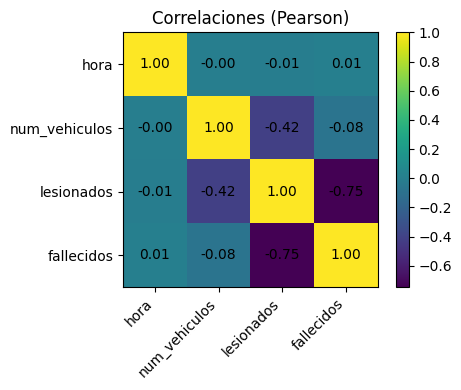

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(corr_pd.values, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr_pd.values[i,j]:.2f}", ha="center", va="center")
plt.title("Correlaciones (Pearson)")
plt.colorbar(); plt.tight_layout(); plt.show()


Las correlaciones muestran varias cosas. Primero, la hora del hecho no se asocia linealmente ni con hechos ni con lesionados o fallecidos. La relación más marcada es la negativa entre lesionados y fallecidos (-0.75) pero al ser negativa, esto sugiere que en un accidente, o hay lesionados o hay fallecidos, y rara vez los dos aparecen altos a la vez.

## PCA

Varianza explicada por componente: [0.4563496  0.26645994]
Varianza explicada: [0.4563496  0.26645994]
+-------------------+--------------------+
|PC1                |PC2                 |
+-------------------+--------------------+
|0.6728789997389198 |-0.312093580050611  |
|0.6701169381121083 |-0.2921804697355011 |
|0.6728789997389198 |-0.312093580050611  |
|-2.7366487888354216|0.8863648454466855  |
|0.6521635375378332 |-0.16274525268728668|
+-------------------+--------------------+
only showing top 5 rows


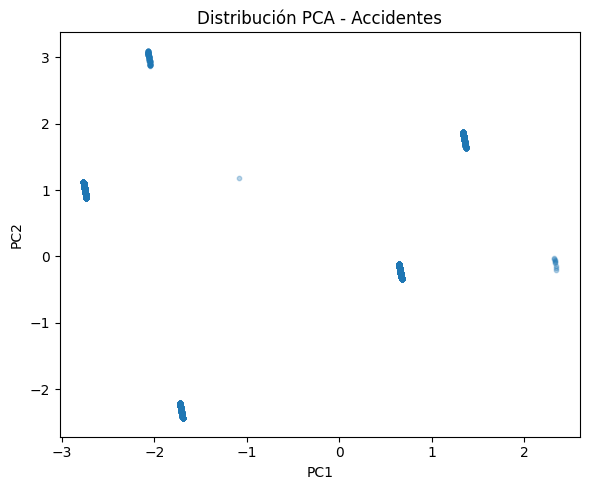

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

num_cols = ["hora", "num_vehiculos", "lesionados", "fallecidos"]

va = VectorAssembler(inputCols=num_cols, outputCol="features", handleInvalid="skip")
vec_df = va.transform(comb_df.na.fill(0, num_cols))

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaled_df = scaler.fit(vec_df).transform(vec_df)

pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
pca_result = pca_model.transform(scaled_df)

print("Varianza explicada por componente:", pca_model.explainedVariance.toArray())

va  = VectorAssembler(inputCols=num_cols, outputCol="features", handleInvalid="skip")
vec = va.transform(comb_df.na.fill({c:0.0 for c in num_cols}))

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaled = scaler.fit(vec).transform(vec)

pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled)
pca_result = pca_model.transform(scaled)

print("Varianza explicada:", pca_model.explainedVariance.toArray())

pca_arr = vector_to_array("pca_features")
pca_2d = (pca_result
          .select(pca_arr.alias("arr"))
          .select(F.col("arr").getItem(0).alias("PC1"),
                  F.col("arr").getItem(1).alias("PC2")))

pca_2d.show(5, truncate=False)

sample_pd = pca_2d.sample(withReplacement=False, fraction=0.1, seed=42).limit(20000).toPandas()

plt.figure(figsize=(6,5))
plt.scatter(sample_pd["PC1"], sample_pd["PC2"], s=10, alpha=0.3)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Distribución PCA - Accidentes")
plt.tight_layout(); plt.show()


DataFrame[cluster: int, count: bigint]

DataFrame[cluster: int, avg_hora: double, avg_num_vehiculos: double, avg_lesionados: double, avg_fallecidos: double]

DataFrame[cluster: bigint, center_hora: double, center_num_vehiculos: double, center_lesionados: double, center_fallecidos: double]

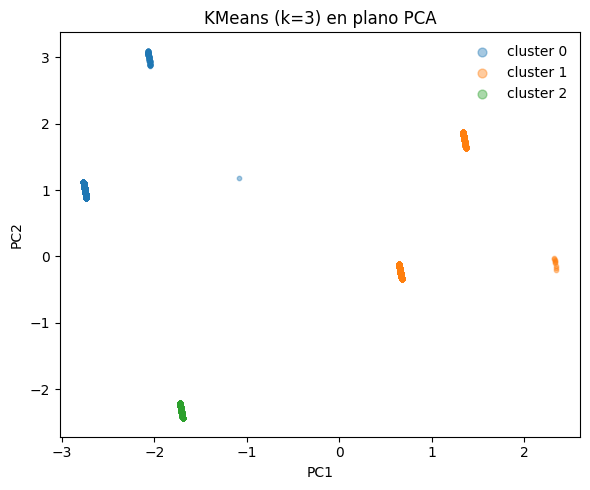

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt

num_cols = ["hora","num_vehiculos","lesionados","fallecidos"]
k = 3
seed = 42

va  = VectorAssembler(inputCols=num_cols, outputCol="features", handleInvalid="skip")
vec = va.transform(comb_df.na.fill({c:0.0 for c in num_cols}))

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(vec)
feat = scaler_model.transform(vec)

# KMeans
km = KMeans(k=k, seed=seed, featuresCol="scaled_features", predictionCol="cluster")
km_model = km.fit(feat)
pred = km_model.transform(feat).select(*num_cols, "cluster", "scaled_features")

display(pred.groupBy("cluster").count().orderBy("cluster"))

charac = (pred.groupBy("cluster")
          .agg(*[F.round(F.avg(c),3).alias(f"avg_{c}") for c in num_cols])
          .orderBy("cluster"))
display(charac)

import numpy as np
std = scaler_model.std.toArray()
mean = scaler_model.mean.toArray()
cent_scaled = np.vstack([c.toArray() if hasattr(c,"toArray") else np.array(c) for c in km_model.clusterCenters()])
cent_unscaled = cent_scaled * std + mean
cent_rows = [tuple([i] + [float(x) for x in cent_unscaled[i]]) for i in range(k)]
cols_center = ["cluster"] + [f"center_{c}" for c in num_cols]
centers_df = spark.createDataFrame(cent_rows, cols_center)
display(centers_df.orderBy("cluster"))

pca = PCA(k=2, inputCol="scaled_features", outputCol="pca2")
pca_model = pca.fit(pred)
pca_res = pca_model.transform(pred)

pca_arr = vector_to_array("pca2")
pca2 = (pca_res
        .select(F.col("cluster"),
                pca_arr.getItem(0).alias("PC1"),
                pca_arr.getItem(1).alias("PC2")))

sample_pd = pca2.sample(withReplacement=False, fraction=0.1, seed=seed).limit(20000).toPandas()

plt.figure(figsize=(6,5))
for c in sorted(sample_pd["cluster"].unique()):
    sub = sample_pd[sample_pd["cluster"]==c]
    plt.scatter(sub["PC1"], sub["PC2"], s=10, alpha=0.4, label=f"cluster {c}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"KMeans (k={k}) en plano PCA")
plt.legend(markerscale=2, frameon=False)
plt.tight_layout(); plt.show()


## Severidad

In [22]:
from pyspark.sql import functions as F

num_cols = ["hora","num_vehiculos","lesionados","fallecidos"]
comb5 = comb_df.select(
    *[F.col(c).cast("double").alias(c) for c in num_cols],
    "anio_int","mes_num","dia_sem_ocu","depto_std","tipo_eve_norm"
).na.fill({"lesionados": 0.0, "fallecidos": 0.0, "num_vehiculos": 0.0})

severidad = (
    F.when( (F.col("fallecidos") == 0) & (F.col("lesionados") < 2), "Leve")
     .when( (F.col("fallecidos") >= 1) | ((F.col("lesionados") >= 2) & (F.col("lesionados") <= 5)), "Moderado")
     .otherwise("Grave")
)

comb_with_sev = comb5.withColumn("severidad", severidad)

dist5 = comb_with_sev.groupBy("severidad").count().orderBy(F.desc("count"))
dist5.show(truncate=False)

tot = comb_with_sev.count()
display(
    dist5.withColumn("porcentaje", F.round(F.col("count")*100.0/tot, 2))
)



+---------+-----+
|severidad|count|
+---------+-----+
|Leve     |64798|
|Moderado |11667|
+---------+-----+



DataFrame[severidad: string, count: bigint, porcentaje: double]

## Division de Train/Test

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

lab_indexer = StringIndexer(inputCol="severidad", outputCol="label", handleInvalid="keep").fit(comb_with_sev)
data_labeled = lab_indexer.transform(comb_with_sev)

# Vector de features
va = VectorAssembler(
    inputCols=["hora","num_vehiculos","lesionados","fallecidos"],
    outputCol="features",
    handleInvalid="keep"
)
data_final = va.transform(data_labeled).select("features","label","severidad","hora","num_vehiculos","lesionados","fallecidos")

# Split 70/30
train_df, test_df = data_final.randomSplit([0.7, 0.3], seed=2025)
print("Train:", train_df.count(), " | Test:", test_df.count())

print("Distribución train")
train_df.groupBy("severidad").count().orderBy(F.desc("count")).show(truncate=False)

print("Distribución test")
test_df.groupBy("severidad").count().orderBy(F.desc("count")).show(truncate=False)


Train: 53645  | Test: 22820
Distribución train
+---------+-----+
|severidad|count|
+---------+-----+
|Leve     |45462|
|Moderado |8183 |
+---------+-----+

Distribución test
+---------+-----+
|severidad|count|
+---------+-----+
|Leve     |19336|
|Moderado |3484 |
+---------+-----+

